In [ ]:
!pip install -q kaggle kagglehub Pillow torchvision pandas

In [ ]:
from google.colab import files
files.upload()   # upload kaggle.json

import os, shutil
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

Saving kaggle.json to kaggle.json


In [ ]:
import kagglehub
path = kagglehub.dataset_download("ifigotin/imagenetmini-1000")
print("Downloaded to:", path)

100%|██████████| 3.92G/3.92G [00:44<00:00, 93.7MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ifigotin/imagenetmini-1000/versions/1


In [ ]:
## Pytorch model

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from einops import rearrange
import torch
import torch.nn as nn
from torch import Tensor
from typing import Tuple, Dict
import numpy as np

# PyTorch Implementation
class MV2(nn.Module):
    def __init__(self, in_channels, out_channels, strides=1, expansion_ratio=1):
        super().__init__()
        hidden_dim = int(in_channels * expansion_ratio)
        self.use_residual = strides == 1 and in_channels == out_channels

        # 1. Point-wise conv (expand)
        self.pw_expand = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU()
        )

        # 2. Depth-wise conv
        self.dw_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=strides, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU()
        )

        # 3. Point-wise linear conv (project)
        self.pw_project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        skip = x
        x = self.pw_expand(x)
        x = self.dw_conv(x)
        x = self.pw_project(x)
        if self.use_residual:
            x = x + skip
        return x


class LocalRepresentation(nn.Module):
    def __init__(self, in_channels, num_filters, out_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, num_filters, kernel_size=3, stride=1, padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(num_filters)
        self.act1 = nn.SiLU()

        self.conv2 = nn.Conv2d(num_filters, out_dim, kernel_size=1, stride=1, padding= 0,bias=False )

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, dim, num_heads, mlp_dim):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True, dropout=0.0)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp_dim = mlp_dim
        self.fc1 = nn.Linear(dim, mlp_dim)
        self.act = nn.SiLU()
        self.fc2 = nn.Linear(mlp_dim, dim)

    def forward(self, x):
        skip = x
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = skip + attn_out

        skip2 = x
        x_norm = self.norm2(x)

        x = self.fc1(x_norm)
        x = self.act(x)

        y1 = self.fc2(x)

        x = skip2 + y1

        return x

class Fusion(nn.Module):
    def __init__(self, in_channels, dim):
        super().__init__()
        self.conv1 = nn.Conv2d(dim, in_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.act1 = nn.SiLU()
        self.conv2 = nn.Conv2d(2*in_channels, in_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(in_channels)
        self.act2 = nn.SiLU()

    def forward(self, x, x_fusion):
        x_f = self.conv1(x_fusion)
        x_f = self.bn1(x_f)
        x_f = self.act1(x_f)

        x_concat = torch.cat([x, x_f], dim=1)

        x_out = self.conv2(x_concat)
        x_out = self.bn2(x_out)
        x_out = self.act2(x_out)

        return x_out

import numpy as np

class MobileViTBlock(nn.Module):
    def __init__(self, in_channels, num_filters, dim, num_heads, patch_size=2, num_layers=1):
        super().__init__()
        self.patch_h = patch_size
        self.patch_w = patch_size
        self.patch_area = patch_size * patch_size

        self.local_rep = LocalRepresentation(in_channels, num_filters, dim)
        self.transformers = nn.ModuleList([
            TransformerEncoder(dim, num_heads=num_heads, mlp_dim=dim*2) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.fusion = Fusion(in_channels, dim)

    def unfolding(self, x: Tensor) -> Tuple[Tensor, Dict]:
        b, c, h, w = x.shape

        # Calculate new dimensions (must be divisible by patch_size)
        new_h = int(np.ceil(h / self.patch_h) * self.patch_h)
        new_w = int(np.ceil(w / self.patch_w) * self.patch_w)
        interpolate = False

        if new_h != h or new_w != w:
            # Use bilinear interpolation to pad feature map
            x = F.interpolate(x, size=(new_h, new_w), mode="bilinear", align_corners=False)
            interpolate = True

        num_patch_h = new_h // self.patch_h
        num_patch_w = new_w // self.patch_w
        num_patches = num_patch_h * num_patch_w

        # [B, C, H, W] --> [B*C*n_h, p_h, n_w, p_w]
        x = x.reshape(b * c * num_patch_h, self.patch_h, num_patch_w, self.patch_w)
        # [B*C*n_h, p_h, n_w, p_w] --> [B*C*n_h, n_w, p_h, p_w]
        x = x.permute(0, 2, 1, 3)
        # [B*C*n_h, n_w, p_h, p_w] --> [B, C, N, P]
        x = x.reshape(b, c, num_patches, self.patch_area)
        # [B, C, N, P] --> [B, P, N, C]
        x = x.permute(0, 3, 2, 1)
        # [B, P, N, C] --> [BP, N, C]
        patches = x.reshape(b * self.patch_area, num_patches, c)

        info = {
            "orig_size": (h, w),
            "batch_size": b,
            "interpolate": interpolate,
            "num_patches_h": num_patch_h,
            "num_patches_w": num_patch_w,
            "total_patches": num_patches
        }
        return patches, info

    def folding(self, x: Tensor, info: Dict) -> Tensor:
        b = info["batch_size"]
        # Use consistent naming: num_patches_h and num_patches_w
        num_patches_h = info["num_patches_h"]
        num_patches_w = info["num_patches_w"]

        h_new = num_patches_h * self.patch_h
        w_new = num_patches_w * self.patch_w
        channels = x.shape[-1]

        # 1. [BP, N, C] --> [B, P, N, C]
        x = x.reshape(b, self.patch_area, info["total_patches"], channels)

        # 2. [B, P, N, C] --> [B, C, N, P]
        x = x.permute(0, 3, 2, 1)

        # 3. [B, C, N, P] --> [B*C*n_h, n_w, p_h, p_w]
        # FIXED: Changed num_patch_h/w to num_patches_h/w
        x = x.reshape(b * channels * num_patches_h, num_patches_w, self.patch_h, self.patch_w)

        # 4. [B*C*n_h, n_w, p_h, p_w] --> [B*C*n_h, p_h, n_w, p_w]
        x = x.permute(0, 2, 1, 3)

        # 5. [B*C*n_h, p_h, n_w, p_w] --> [B, C, H, W]
        x = x.reshape(b, channels, h_new, w_new)

        # 6. Revert interpolation if it was applied
        if info["interpolate"]:
            x = F.interpolate(x, size=info["orig_size"], mode="bilinear", align_corners=False)
        return x

    def forward(self, x):
        res = x
        x = self.local_rep(x)

        # Global Representation (Transformer)
        patches, info = self.unfolding(x)
        for transformer in self.transformers:
            patches = transformer(patches)
        patches = self.norm(patches)

        x_global = self.folding(patches, info)

        # Fusion
        out = self.fusion(res, x_global)
        return out


class MobileViT_XXS(nn.Module):
    def __init__(self, in_channels=3, num_classes=1000):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU()
        )

        # Stage 1
        self.mv2_1 = MV2(16, 16, expansion_ratio=2)

        # Stage 2
        self.mv2_2a = MV2(16, 24, strides=2, expansion_ratio=2)
        self.mv2_2b = MV2(24, 24, expansion_ratio=2)
        self.mv2_2c = MV2(24, 24, expansion_ratio=2)

        # Stage 3
        self.mv2_3a = MV2(24, 48, strides=2, expansion_ratio=2)
        self.mvit_3b = MobileViTBlock(48, 48, 64,num_heads = 2, patch_size=2, num_layers=2)

        # Stage 4
        self.mv2_4a = MV2(48, 64, strides=2, expansion_ratio=2)
        self.mvit_4b = MobileViTBlock(64, 64, 80,num_heads = 4 ,patch_size=2, num_layers=4)

        # Stage 5
        self.mv2_5a = MV2(64, 80, strides=2, expansion_ratio=2)
        self.mvit_5b = MobileViTBlock(80, 80, 96,num_heads = 4, patch_size=2, num_layers=3)

        # Head
        self.head_conv = nn.Sequential(
            nn.Conv2d(80, 320, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(320),
            nn.SiLU()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=0.1)
        self.classifier = nn.Linear(320, num_classes)

    def forward(self, x):
        x = self.stem(x)


        x = self.mv2_1(x)


        x = self.mv2_2a(x)
        x = self.mv2_2b(x)
        x = self.mv2_2c(x)

        x = self.mv2_3a(x)

        x = self.mvit_3b(x)

        x = self.mv2_4a(x)
        x = self.mvit_4b(x)

        x = self.mv2_5a(x)
        x = self.mvit_5b(x)

        x = self.head_conv(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

my_model = MobileViT_XXS(in_channels=3, num_classes=1000)
x = torch.randn(2, 3, 224, 224)  # batch of 2 images
y = my_model(x)
print(y.shape)

# Mappint Function From Pretrained Apple Model

def load_apple_weights(my_model, apple_state_dict):
    """
    Corrected mapping that includes running_mean and running_var for ALL layers.
    """
    new_state_dict = {}

    # Helper to map weight, bias, running_mean, and running_var for BN
    def map_bn(my_prefix, apple_prefix):
        m = {}
        m[f'{my_prefix}.weight'] = apple_state_dict[f'{apple_prefix}.weight']
        m[f'{my_prefix}.bias']   = apple_state_dict[f'{apple_prefix}.bias']
        m[f'{my_prefix}.running_mean'] = apple_state_dict[f'{apple_prefix}.running_mean']
        m[f'{my_prefix}.running_var']  = apple_state_dict[f'{apple_prefix}.running_var']
        return m

    # 1. Stem
    new_state_dict['stem.0.weight'] = apple_state_dict['mobilevit.conv_stem.convolution.weight']
    new_state_dict.update(map_bn('stem.1', 'mobilevit.conv_stem.normalization'))

    # 2. MV2 Helper
    def map_mv2(my_prefix, apple_prefix):
        m = {}
        # Expand
        m[f'{my_prefix}.pw_expand.0.weight'] = apple_state_dict[f'{apple_prefix}.expand_1x1.convolution.weight']
        m.update(map_bn(f'{my_prefix}.pw_expand.1', f'{apple_prefix}.expand_1x1.normalization'))
        # Depthwise
        m[f'{my_prefix}.dw_conv.0.weight'] = apple_state_dict[f'{apple_prefix}.conv_3x3.convolution.weight']
        m.update(map_bn(f'{my_prefix}.dw_conv.1', f'{apple_prefix}.conv_3x3.normalization'))
        # Project
        m[f'{my_prefix}.pw_project.0.weight'] = apple_state_dict[f'{apple_prefix}.reduce_1x1.convolution.weight']
        m.update(map_bn(f'{my_prefix}.pw_project.1', f'{apple_prefix}.reduce_1x1.normalization'))
        return m

    # Stage 1 & 2
    new_state_dict.update(map_mv2('mv2_1', 'mobilevit.encoder.layer.0.layer.0'))
    new_state_dict.update(map_mv2('mv2_2a', 'mobilevit.encoder.layer.1.layer.0'))
    new_state_dict.update(map_mv2('mv2_2b', 'mobilevit.encoder.layer.1.layer.1'))
    new_state_dict.update(map_mv2('mv2_2c', 'mobilevit.encoder.layer.1.layer.2'))
    # Stage 3-5 Downsampling MV2s
    new_state_dict.update(map_mv2('mv2_3a', 'mobilevit.encoder.layer.2.downsampling_layer'))
    new_state_dict.update(map_mv2('mv2_4a', 'mobilevit.encoder.layer.3.downsampling_layer'))
    new_state_dict.update(map_mv2('mv2_5a', 'mobilevit.encoder.layer.4.downsampling_layer'))

    # 3. MobileViT Block
    def map_mvit_block(my_name, apple_idx):
        m = {}
        apple_base = f'mobilevit.encoder.layer.{apple_idx}'

        # Local Rep
        m[f'{my_name}.local_rep.conv1.weight'] = apple_state_dict[f'{apple_base}.conv_kxk.convolution.weight']
        m.update(map_bn(f'{my_name}.local_rep.bn1', f'{apple_base}.conv_kxk.normalization'))
        m[f'{my_name}.local_rep.conv2.weight'] = apple_state_dict[f'{apple_base}.conv_1x1.convolution.weight']

        # Block final Norm (LayerNorm - no running stats)
        m[f'{my_name}.norm.weight'] = apple_state_dict[f'{apple_base}.layernorm.weight']
        m[f'{my_name}.norm.bias']   = apple_state_dict[f'{apple_base}.layernorm.bias']

        # Fusion - FIXED: Now includes running_mean and running_var
        m[f'{my_name}.fusion.conv1.weight'] = apple_state_dict[f'{apple_base}.conv_projection.convolution.weight']
        m.update(map_bn(f'{my_name}.fusion.bn1', f'{apple_base}.conv_projection.normalization'))

        m[f'{my_name}.fusion.conv2.weight'] = apple_state_dict[f'{apple_base}.fusion.convolution.weight']
        m.update(map_bn(f'{my_name}.fusion.bn2', f'{apple_base}.fusion.normalization'))

        # Transformers
        num_layers = len(getattr(my_model, my_name).transformers)
        for i in range(num_layers):
            my_t = f'{my_name}.transformers.{i}'
            apple_t = f'{apple_base}.transformer.layer.{i}'

            m[f'{my_t}.norm1.weight'] = apple_state_dict[f'{apple_t}.layernorm_before.weight']
            m[f'{my_t}.norm1.bias']   = apple_state_dict[f'{apple_t}.layernorm_before.bias']
            m[f'{my_t}.norm2.weight'] = apple_state_dict[f'{apple_t}.layernorm_after.weight']
            m[f'{my_t}.norm2.bias']   = apple_state_dict[f'{apple_t}.layernorm_after.bias']

            m[f'{my_t}.fc1.weight'] = apple_state_dict[f'{apple_t}.intermediate.dense.weight']
            m[f'{my_t}.fc1.bias']   = apple_state_dict[f'{apple_t}.intermediate.dense.bias']
            m[f'{my_t}.fc2.weight'] = apple_state_dict[f'{apple_t}.output.dense.weight']
            m[f'{my_t}.fc2.bias']   = apple_state_dict[f'{apple_t}.output.dense.bias']

            # MultiheadAttention mapping
            attn_path = f'{apple_t}.attention'
            qw = apple_state_dict[f'{attn_path}.attention.query.weight']
            kw = apple_state_dict[f'{attn_path}.attention.key.weight']
            vw = apple_state_dict[f'{attn_path}.attention.value.weight']
            m[f'{my_t}.attn.in_proj_weight'] = torch.cat([qw, kw, vw], dim=0)

            qb = apple_state_dict[f'{attn_path}.attention.query.bias']
            kb = apple_state_dict[f'{attn_path}.attention.key.bias']
            vb = apple_state_dict[f'{attn_path}.attention.value.bias']
            m[f'{my_t}.attn.in_proj_bias'] = torch.cat([qb, kb, vb], dim=0)

            m[f'{my_t}.attn.out_proj.weight'] = apple_state_dict[f'{attn_path}.output.dense.weight']
            m[f'{my_t}.attn.out_proj.bias']   = apple_state_dict[f'{attn_path}.output.dense.bias']
        return m

    new_state_dict.update(map_mvit_block('mvit_3b', 2))
    new_state_dict.update(map_mvit_block('mvit_4b', 3))
    new_state_dict.update(map_mvit_block('mvit_5b', 4))

    # 4. Final Head - FIXED: Now includes running_mean and running_var
    new_state_dict['head_conv.0.weight'] = apple_state_dict['mobilevit.conv_1x1_exp.convolution.weight']
    new_state_dict.update(map_bn('head_conv.1', 'mobilevit.conv_1x1_exp.normalization'))

    new_state_dict['classifier.weight'] = apple_state_dict['classifier.weight']
    new_state_dict['classifier.bias']   = apple_state_dict['classifier.bias']

    # Load
    my_model.load_state_dict(new_state_dict, strict=False)
    my_model.eval() # CRITICAL for BatchNorm inference
    print("✅ Successfully mapped weights and enabled eval mode.")

from transformers import MobileViTForImageClassification

# The correct ID for XXS is 'apple/mobilevit-xx-small'
apple_model = MobileViTForImageClassification.from_pretrained("apple/mobilevit-xx-small")

apple_state_dict = torch.load("pytorch_model.bin", map_location="cpu")
apple_model.load_state_dict(apple_state_dict)
load_apple_weights(my_model, apple_state_dict)

torch.Size([2, 1000])


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.22M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/5.15M [00:00<?, ?B/s]

✅ Successfully mapped weights and enabled eval mode.


In [ ]:
import os, glob, random, math, warnings
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
import torchvision.transforms as T
warnings.filterwarnings("ignore")

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def load_images(image_paths):
    tensors, failed = [], 0
    for p in image_paths:
        try:
            tensors.append(transform(Image.open(p).convert("RGB")).unsqueeze(0))
        except:
            failed += 1
    print(f"Loaded {len(tensors)} images ({failed} failed)")
    return tensors

def compute_fixed_point(v_min, v_max, num_bits=32):
    abs_max = max(abs(v_min), abs(v_max), 1e-12)
    m = max(math.ceil(math.log2(abs_max + 1e-12)), 0)
    int_bits = m + 1
    Q = num_bits - int_bits
    scale = 2.0 ** (-Q)
    max_repr = (2 ** (num_bits - 1) - 1) * scale
    min_repr = -(2 ** (num_bits - 1)) * scale
    return {
        "v_min": round(v_min, 5), "v_max": round(v_max, 5),
        "abs_max": round(abs_max, 5), "int_bits": int_bits,
        "Q": Q, "scale": scale, "max_repr": round(max_repr, 5),
        "overflow": (v_max > max_repr) or (v_min < min_repr),
        "format": f"Q{m}.{Q}",
    }

class Profiler:
    def __init__(self, model, num_bits=32, device="cpu"):
        self.model = model.to(device).eval()
        self.num_bits = num_bits
        self.device = device
        self.stats = {}
        self._hooks = []

    def _hook(self, name, ltype):
        def fn(module, input, output):
            out = output[0] if isinstance(output, tuple) else output
            if not isinstance(out, torch.Tensor): return
            with torch.no_grad():
                mn, mx = out.min().item(), out.max().item()
            if name not in self.stats:
                self.stats[name] = {"min": mn, "max": mx, "type": ltype}
            else:
                self.stats[name]["min"] = min(self.stats[name]["min"], mn)
                self.stats[name]["max"] = max(self.stats[name]["max"], mx)
        return fn

    def attach(self):
        for name, module in self.model.named_modules():
            if name == "": continue
            self._hooks.append(module.register_forward_hook(self._hook(name, type(module).__name__)))
        print(f"Attached {len(self._hooks)} hooks")

    def detach(self):
        for h in self._hooks: h.remove()
        self._hooks = []

    @torch.no_grad()
    def run(self, tensors, batch_size=16):
        print(f"Profiling {len(tensors)} images...")
        for i in range(0, len(tensors), batch_size):
            batch = torch.cat(tensors[i:i+batch_size]).to(self.device)
            self.model(batch)
        print("Done.")

    def report(self):
        rows = []
        for name, s in self.stats.items():
            fp = compute_fixed_point(s["min"], s["max"], self.num_bits)
            rows.append({"layer": name, "type": s["type"], **fp, "num_bits": self.num_bits})
        df = pd.DataFrame(rows)

        W = 135
        print("\n" + "="*W)
        print(f"  Fixed-Point Report  |  int{self.num_bits}  |  MobileViT-XXS")
        print("="*W)
        print(f"{'LAYER':<58} {'TYPE':<20} {'OUT_MIN':>8} {'OUT_MAX':>8} {'ABS_MAX':>8} {'INT_BITS':>8} {'Q':>4} {'SCALE':>11} {'FORMAT':>9} {'STATUS':>7}")
        print("-"*W)
        for _, r in df.iterrows():
            status = "⚠️ OVF" if r["overflow"] else "  OK"
            print(f"{r['layer']:<58} {r['type']:<20} {r['v_min']:>8.4f} {r['v_max']:>8.4f} "
                  f"{r['abs_max']:>8.4f} {int(r['int_bits']):>8} {int(r['Q']):>4} "
                  f"{r['scale']:>11.2e} {r['format']:>9} {status:>7}")
        print("="*W)

        overflows = df[df["overflow"]]
        if len(overflows):
            print(f"\n⚠️  {len(overflows)} layers overflow int{self.num_bits}:")
            for _, r in overflows.iterrows():
                print(f"   {r['layer']} | abs_max={r['abs_max']} > max_repr={r['max_repr']}")
        else:
            print(f"\n✅ All {len(df)} layers fit within int{self.num_bits}.")

        print(f"\nQ range: {int(df['Q'].min())} → {int(df['Q'].max())}")
        print(f"INT_BITS range: {int(df['int_bits'].min())} → {int(df['int_bits'].max())}")

        print("\n📊 Summary by Layer Type:")
        print(df.groupby("type").agg(
            count=("layer","count"),
            max_abs_max=("abs_max","max"),
            min_Q=("Q","min"),
            max_Q=("Q","max"),
        ).to_string())

        df.to_csv("mobilevit_fixedpoint.csv", index=False)
        print("\n✅ Saved: mobilevit_fixedpoint.csv")
        return df

# ── Run ───────────────────────────────────────────────────────────────────────
all_images = glob.glob(os.path.join(path, "**", "*.JPEG"), recursive=True) + \
             glob.glob(os.path.join(path, "**", "*.jpg"),  recursive=True)
random.seed(42)
random.shuffle(all_images)
tensors = load_images(all_images[:300])

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

profiler = Profiler(my_model, num_bits=32, device=device)
profiler.attach()
profiler.run(tensors, batch_size=16)
profiler.detach()
df = profiler.report()

Loaded 300 images (0 failed)
Device: cpu
Attached 212 hooks
Profiling 300 images...
Done.

  Fixed-Point Report  |  int32  |  MobileViT-XXS
LAYER                                                      TYPE                  OUT_MIN  OUT_MAX  ABS_MAX INT_BITS    Q       SCALE    FORMAT  STATUS
---------------------------------------------------------------------------------------------------------------------------------------
stem.0                                                     Conv2d                -8.4441   9.3547   9.3547        5   27    7.45e-09     Q4.27      OK
stem.1                                                     BatchNorm2d          -64.4150  65.1655  65.1655        8   24    5.96e-08     Q7.24      OK
stem.2                                                     SiLU                  -0.2785  65.1655  65.1655        8   24    5.96e-08     Q7.24      OK
stem                                                       Sequential            -0.2785  65.1655  65.1655        8   24

Saving mobilevit_fixedpoint.csv to mobilevit_fixedpoint (2).csv


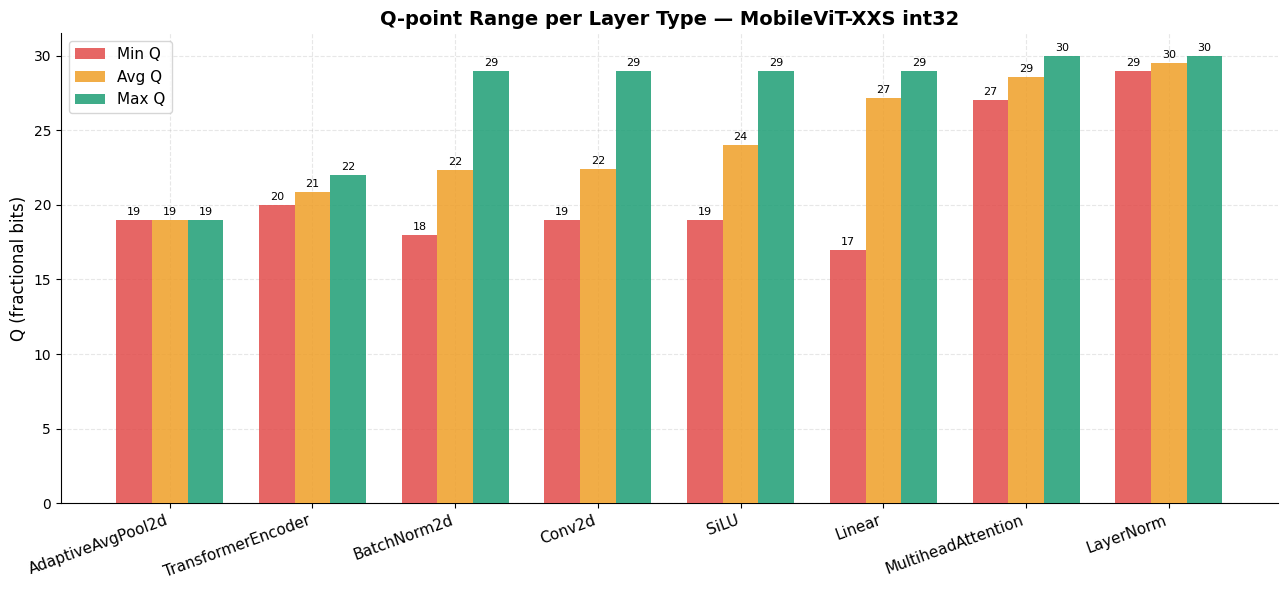

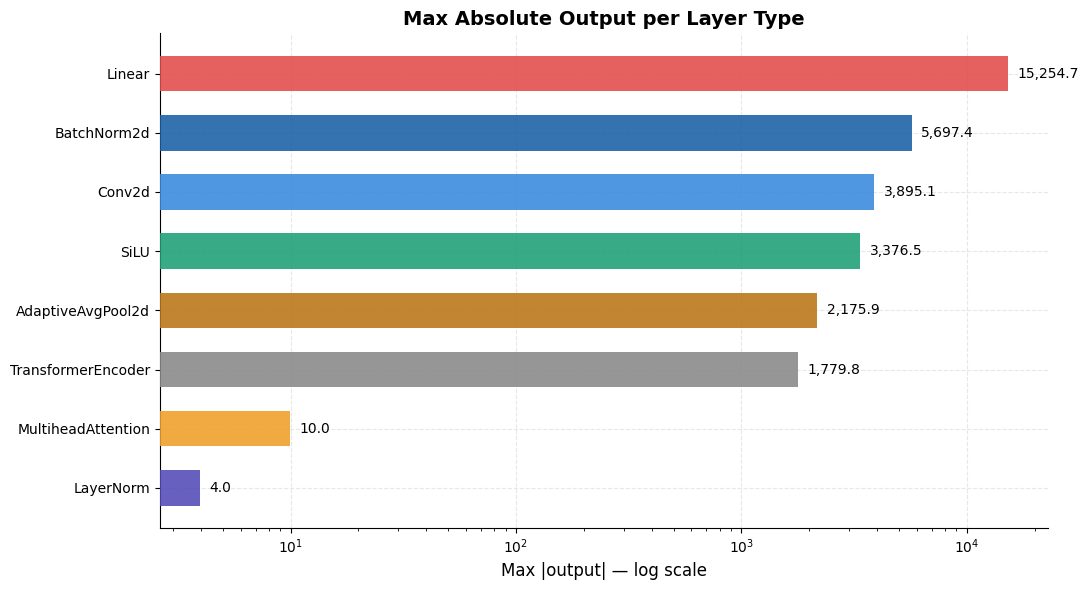

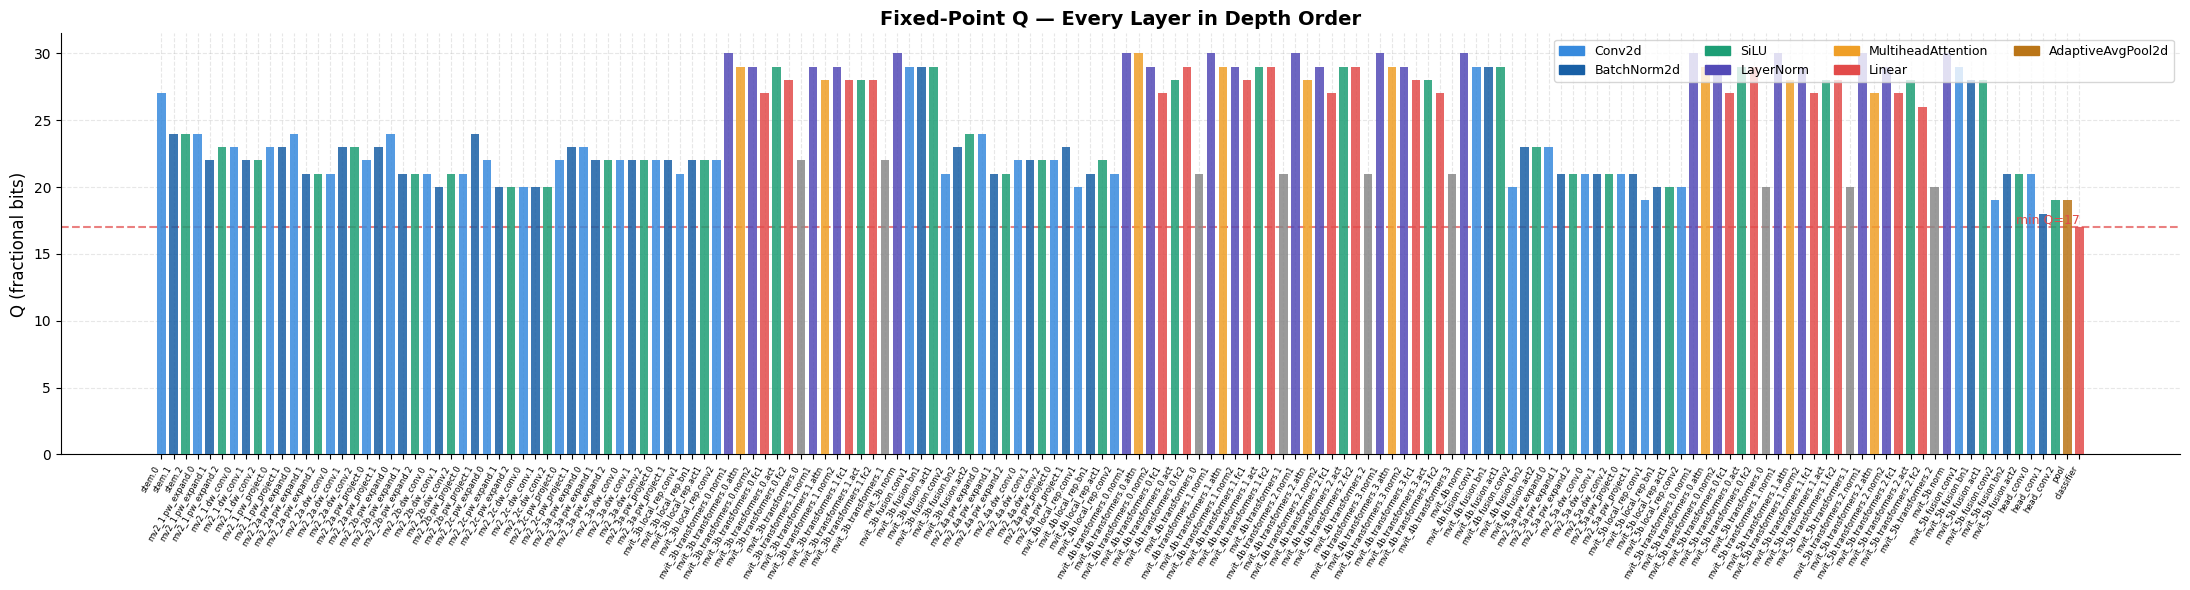

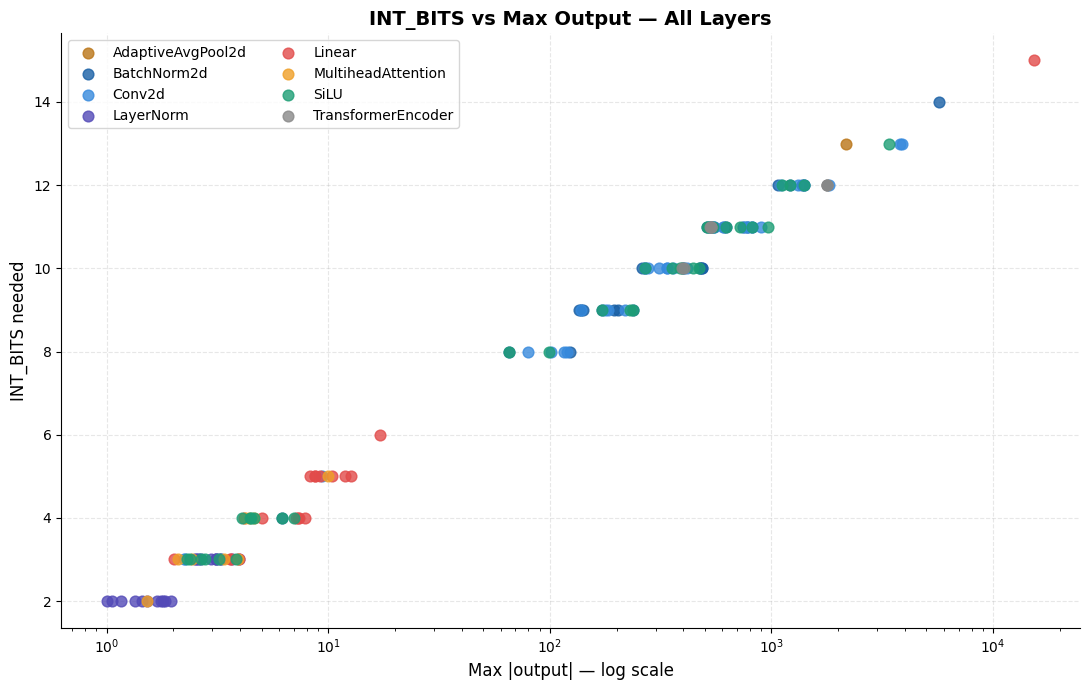

                       layer               type        v_min      v_max     abs_max  int_bits  Q format
                      stem.0             Conv2d     -8.44413    9.35472     9.35472         5 27  Q4.27
                      stem.1        BatchNorm2d    -64.41502   65.16547    65.16547         8 24  Q7.24
                      stem.2               SiLU     -0.27846   65.16547    65.16547         8 24  Q7.24
           mv2_1.pw_expand.0             Conv2d    -79.56577   34.14492    79.56577         8 24  Q7.24
           mv2_1.pw_expand.1        BatchNorm2d   -476.36874  230.39098   476.36874        10 22  Q9.22
           mv2_1.pw_expand.2               SiLU     -0.27846  230.39098   230.39098         9 23  Q8.23
             mv2_1.dw_conv.0             Conv2d   -182.69794   56.12319   182.69794         9 23  Q8.23
             mv2_1.dw_conv.1        BatchNorm2d   -237.07834  267.92490   267.92490        10 22  Q9.22
             mv2_1.dw_conv.2               SiLU     -0.27846  26

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from google.colab import files

# ── upload your CSV ───────────────────────────────────────────────────────────
uploaded = files.upload()  # select mobilevit_fixedpoint.csv
df = pd.read_csv(list(uploaded.keys())[0])

# keep only leaf layers (no Sequential / wrapper modules)
skip_types = {'Sequential','MV2','MobileViTBlock','Fusion','LocalRepresentation'}
df = df[~df['type'].isin(skip_types)].reset_index(drop=True)

type_colors = {
    'Conv2d':            '#378ADD',
    'BatchNorm2d':       '#185FA5',
    'SiLU':              '#1D9E75',
    'LayerNorm':         '#534AB7',
    'MultiheadAttention':'#EF9F27',
    'Linear':            '#E24B4A',
    'AdaptiveAvgPool2d': '#BA7517',
}
df['color'] = df['type'].map(type_colors).fillna('#888888')

plt.rcParams.update({
    'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,
    'grid.alpha':0.3,'grid.linestyle':'--','figure.facecolor':'white',
})

# ════════════════════════════════════════════════════════
# CHART 1 — Q per layer type (grouped bar: min / avg / max)
# ════════════════════════════════════════════════════════
grp = df.groupby('type')['Q'].agg(['min','mean','max']).reset_index()
grp = grp.sort_values('mean')
fig, ax = plt.subplots(figsize=(13,6))
x, w = np.arange(len(grp)), 0.25
b1 = ax.bar(x-w, grp['min'],  w, label='Min Q',  color='#E24B4A', alpha=0.85, zorder=3)
b2 = ax.bar(x,   grp['mean'], w, label='Avg Q',  color='#EF9F27', alpha=0.85, zorder=3)
b3 = ax.bar(x+w, grp['max'],  w, label='Max Q',  color='#1D9E75', alpha=0.85, zorder=3)
for bar in list(b1)+list(b2)+list(b3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(grp['type'], rotation=20, ha='right', fontsize=11)
ax.set_ylabel('Q (fractional bits)', fontsize=12)
ax.set_title('Q-point Range per Layer Type — MobileViT-XXS int32', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════
# CHART 2 — Max abs output per layer type (horizontal log)
# ════════════════════════════════════════════════════════
grp2 = df.groupby('type')['abs_max'].max().reset_index().sort_values('abs_max')
cols2 = [type_colors.get(t,'#888') for t in grp2['type']]
fig, ax = plt.subplots(figsize=(11,6))
bars = ax.barh(grp2['type'], grp2['abs_max'], color=cols2, alpha=0.88, zorder=3, height=0.6)
ax.set_xscale('log')
ax.set_xlabel('Max |output| — log scale', fontsize=12)
ax.set_title('Max Absolute Output per Layer Type', fontsize=14, fontweight='bold')
for bar, v in zip(bars, grp2['abs_max']):
    ax.text(v*1.1, bar.get_y()+bar.get_height()/2, f'{v:,.1f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════
# CHART 3 — Q for every layer along network depth
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(22,6))
ax.bar(np.arange(len(df)), df['Q'], color=df['color'], alpha=0.85, zorder=3, width=0.7)
ax.set_xticks(np.arange(len(df)))
ax.set_xticklabels(df['layer'], rotation=60, ha='right', fontsize=6)
ax.set_ylabel('Q (fractional bits)', fontsize=12)
ax.set_title('Fixed-Point Q — Every Layer in Depth Order', fontsize=14, fontweight='bold')
mn = df['Q'].min()
ax.axhline(y=mn, color='#E24B4A', linestyle='--', alpha=0.7)
ax.text(len(df)-1, mn+0.3, f'min Q={mn}', fontsize=9, color='#E24B4A', ha='right')
patches = [mpatches.Patch(color=c, label=t) for t,c in type_colors.items()]
ax.legend(handles=patches, fontsize=9, ncol=4, loc='upper right')
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════
# CHART 4 — INT_BITS vs ABS_MAX scatter (all layers)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11,7))
for ltype, grp3 in df.groupby('type'):
    ax.scatter(grp3['abs_max'], grp3['int_bits'],
               color=type_colors.get(ltype,'#888'),
               label=ltype, s=60, alpha=0.8, zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Max |output| — log scale', fontsize=12)
ax.set_ylabel('INT_BITS needed', fontsize=12)
ax.set_title('INT_BITS vs Max Output — All Layers', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
plt.tight_layout(); plt.show()

print(df[['layer','type','v_min','v_max','abs_max','int_bits','Q','format']].to_string(index=False))